In [1]:
%load_ext autoreload
%autoreload 2
import time

import jax
import matplotlib.pyplot as plt

from eci.adapter import SimulationAdapter
from eci.environment import Environment
from eci.visualizer import SimulationVisualizer
from eci.voting_system.plurality import _vote_plurality

In [2]:
env = Environment(num_voters=10, num_candidates=2, num_preferences=2)
env.num_simulations = 10
env.initialize_network()
# intiatialize random key
key = jax.random.PRNGKey(int(time.time()))
# run n simulations
sim = env.run_n_simulation(_vote_plurality, key, 10)
# update the agents with the results
env._update_agents()
# use result to create dataframe for plotting
env.df = env.create_data_frame()

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_75932/136902706.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


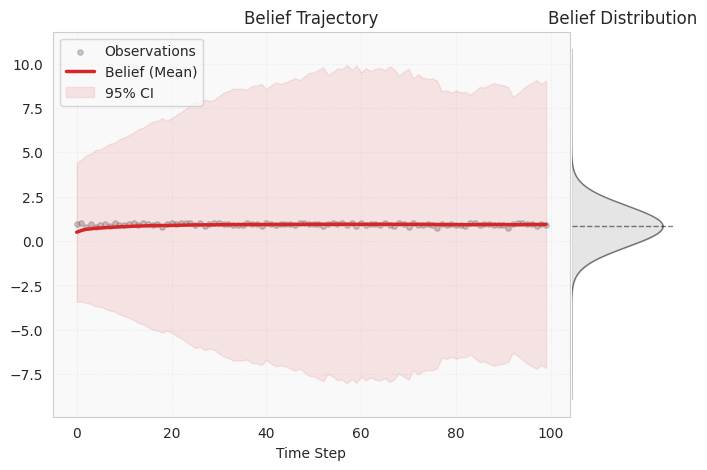

In [3]:
# 1. Initialisation viz and adapter
viz = SimulationVisualizer()
adapter = SimulationAdapter()
traj_data = adapter.get_voter_trajectory_data(env, voter_id=0)
fig, ax1, ax2 = viz.plot_belief_trajectory(
    **traj_data,
)
ax1.set_title("Belief Trajectory")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
ax2.set_title("Belief Distribution")
fig.set_size_inches(8, 5)
plt.show()

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Round 1'}, xlabel='Vote Share', ylabel='Density'>,
        <Axes: title={'center': 'Round 2'}, xlabel='Vote Share'>],
       dtype=object))

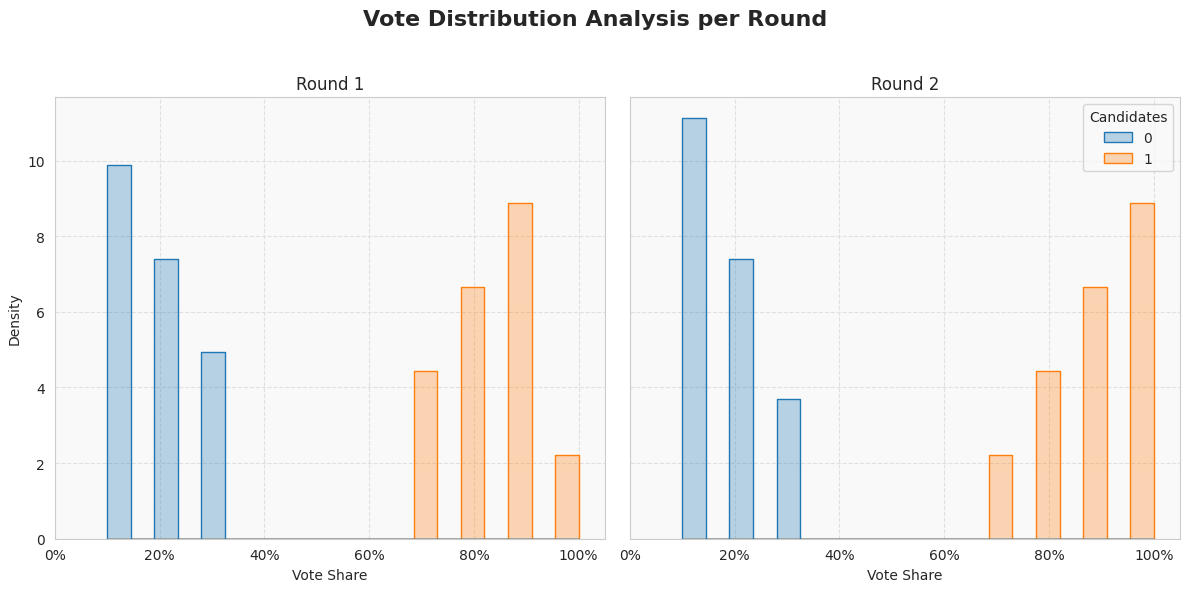

In [4]:
votes_data = adapter.extract_vote_counts(env.df)
viz.plot_vote_proportions(vote_counts=votes_data)

(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'T0'}>, <Axes: title={'center': 'T1'}>],
       dtype=object))

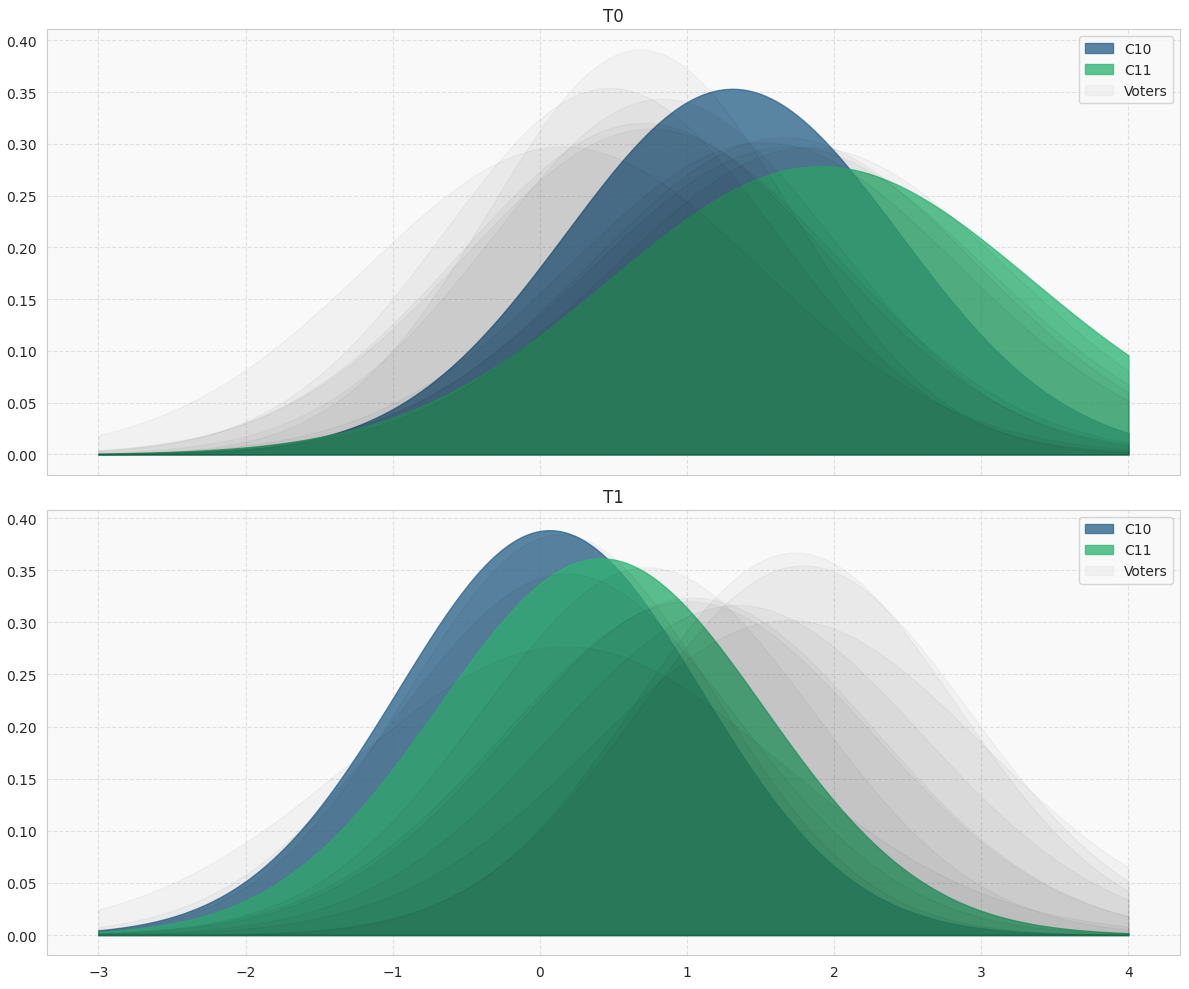

In [ ]:
data = adapter.prepare_preference_data(env)
viz.plot_preference_distributions(data)